# 2D Likelihood Contour: GW Frequency vs Pulsar Distance

This notebook generates **N** random pulsars and **M** random continuous
gravitational wave (CGW) sources, then sweeps the PTA log-likelihood over
a 2D grid of:

- **GW frequency** ($\log_{10} f_{\rm gw}$) of one CW source (x-axis)
- **Pulsar distance** (PX, in kpc) of one target pulsar (y-axis)

The result is a contour plot showing how the likelihood constrains these
two parameters jointly.

In [9]:
%matplotlib widget
import matplotlib.pyplot as plt

In [10]:
from __future__ import annotations

from loguru import logger
logger.disable("pint")

from io import StringIO

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import astropy.units as u
import pint.models as pm
import pint.simulation as psim

from jaxpint import build_timing_model, pint_toas_to_jax
from jaxpint.bridge.model_conversion import pint_model_to_params
from jaxpint.pta.likelihood import PTAConfig, pta_logL
from jaxpint.pta.params import GlobalParams
from jaxpint.pta.signals.cw import CWInjector
from jaxpint.simulation import apply_delay_to_toas

jax.config.update("jax_enable_x64", True)

# ---- Configuration ----
N_PULSARS = 10
M_CW_SOURCES = 1
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 60000.0       # ~8 yr observation span
TOA_ERROR = 1e-8         # 10 ns
FREQ = 1400.0            # MHz
SEED = 42

## Generate random pulsars

Each pulsar gets a random sky position, spin frequency, spindown rate, and
distance. The par file includes spindown (F0, F1), astrometry (RAJ, DECJ, PX),
and unscaled white noise (EFAC = 1).

In [11]:
rng = np.random.default_rng(SEED)


def generate_random_par(idx: int, rng: np.random.Generator) -> str:
    """Generate a .par string for a simple spindown + white noise pulsar."""
    ra_hours = rng.uniform(0, 24)
    dec_deg = np.degrees(np.arcsin(rng.uniform(-1, 1)))

    ra_h = int(ra_hours)
    ra_m = int((ra_hours - ra_h) * 60)
    ra_s = (ra_hours - ra_h - ra_m / 60) * 3600

    dec_sign = "+" if dec_deg >= 0 else "-"
    dec_abs = abs(dec_deg)
    dec_d = int(dec_abs)
    dec_m = int((dec_abs - dec_d) * 60)
    dec_s = (dec_abs - dec_d - dec_m / 60) * 3600

    f0 = rng.uniform(100, 500)
    f1 = -10 ** rng.uniform(-16, -14)
    px_kpc = rng.uniform(0.5, 3.0)  # distance in kpc (stored as PX)

    return f"""\
PSR           J{ra_h:02d}{ra_m:02d}{dec_sign}{dec_d:02d}{dec_m:02d}_{idx:02d}
RAJ           {ra_h:02d}:{ra_m:02d}:{ra_s:08.5f}
DECJ          {dec_sign}{dec_d:02d}:{dec_m:02d}:{dec_s:07.4f}
F0            {f0:.10f}
F1            {f1:.6e}
PEPOCH        {START_MJD:.1f}
PX            {px_kpc:.4f}
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0
"""


par_strings = [generate_random_par(i, rng) for i in range(N_PULSARS)]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars")
print(f"Example .par:\n{par_strings[0]}")

Generated 10 pulsars
Example .par:
PSR           J1834-0701_00
RAJ           18:34:29.80260
DECJ          -07:01:17.6778
F0            443.4391679646
F1            -2.481624e-15
PEPOCH        57000.0
PX            0.7354
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0



## Generate fake TOAs and convert to JaxPINT

In [12]:
toa_data_list = []
pulsar_params_list = []
timing_models = []
noise_models = []

for i, model in enumerate(pint_models):
    toas = psim.make_fake_toas_uniform(
        START_MJD, END_MJD, N_TOAS, model,
        obs="GBT", error=TOA_ERROR * u.s, freq=FREQ * u.MHz,
    )
    toa_data = pint_toas_to_jax(toas, model)
    par_result = pint_model_to_params(model)
    tm, nm = build_timing_model(model, toas)

    toa_data_list.append(toa_data)
    pulsar_params_list.append(par_result.params)
    timing_models.append(tm)
    noise_models.append(nm)

    px_val = float(par_result.params.param_value("PX"))
    print(f"  Pulsar {i}: {model.PSR.value:>20s}  PX(dist)={px_val:.2f} kpc  "
          f"F0={float(par_result.params.param_value('F0')):.1f} Hz")

print(f"\nAll {N_PULSARS} pulsars loaded.")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


  Pulsar 0:        J1834-0701_00  PX(dist)=0.74 kpc  F0=443.4 Hz
  Pulsar 1:        J2324+3129_01  PX(dist)=1.63 kpc  F0=414.4 Hz
  Pulsar 2:        J0853+5835_02  PX(dist)=1.61 kpc  F0=357.5 Hz
  Pulsar 3:        J0527+0616_03  PX(dist)=2.08 kpc  F0=125.5 Hz
  Pulsar 4:        J1811-1654_04  PX(dist)=2.45 kpc  F0=488.3 Hz
  Pulsar 5:        J0440-0348_05  PX(dist)=2.21 kpc  F0=117.5 Hz
  Pulsar 6:        J1752+6913_06  PX(dist)=1.67 kpc  F0=230.3 Hz
  Pulsar 7:        J0432-4744_07  PX(dist)=2.17 kpc  F0=290.3 Hz
  Pulsar 8:        J1029+4142_08  PX(dist)=2.58 kpc  F0=380.1 Hz
  Pulsar 9:        J1918-1300_09  PX(dist)=0.85 kpc  F0=215.3 Hz

All 10 pulsars loaded.


## Set up M CW sources and inject into TOAs

We place M continuous gravitational wave sources at random sky locations with
random nHz-band GW frequencies and strain amplitude $h = 10^{-14}$.

In [13]:
# Compute pulsar unit vectors from RAJ/DECJ
positions = []
for model in pint_models:
    ra_rad = model.RAJ.quantity.to(u.rad).value
    dec_rad = model.DECJ.quantity.to(u.rad).value
    pos = np.array([
        np.cos(dec_rad) * np.cos(ra_rad),
        np.cos(dec_rad) * np.sin(ra_rad),
        np.sin(dec_rad),
    ])
    positions.append(pos)
positions = jnp.array(np.array(positions))

# True strain for injection (source 0)
TRUE_LOG10_H = -15.0

# Create M CW sources
cw_injectors = []
for m in range(M_CW_SOURCES):
    inj = CWInjector(
        positions,
        prefix=f"cw{m}_",
        initial_values={
            "log10_h": TRUE_LOG10_H,
            "cos_gwtheta": rng.uniform(-1, 1),
            "gwphi": rng.uniform(0, 2 * np.pi),
            "log10_fgw": rng.uniform(-9, -7),
        },
    )
    cw_injectors.append(inj)
    print(f"  CW source {m}: cos_gwtheta={inj.param_spec['cos_gwtheta']:.3f}, "
          f"gwphi={inj.param_spec['gwphi']:.3f}, "
          f"log10_fgw={inj.param_spec['log10_fgw']:.2f}")

# Store true injected frequency for source 0 (sweep variable)
TRUE_LOG10_FGW = float(cw_injectors[0].param_spec['log10_fgw'])

# Register global parameters for all sources
gp = GlobalParams.empty()
for inj in cw_injectors:
    gp = inj.register_params(gp)

# Inject all CW signals into TOAs
injected_toa_data_list = []
for i in range(N_PULSARS):
    td = toa_data_list[i]
    total_delay = jnp.zeros(td.n_toas)
    for inj in cw_injectors:
        total_delay += inj.delay(i, td, pulsar_params_list[i], gp)
    injected_toa_data_list.append(apply_delay_to_toas(td, total_delay))

# Build PTA config
config = PTAConfig(
    toa_data_list=tuple(injected_toa_data_list),
    timing_models=tuple(timing_models),
    noise_models=tuple(noise_models),
    signal_injectors=tuple(cw_injectors),
)

pp_tuple = tuple(pulsar_params_list)
print(f"\nPTA config built with {M_CW_SOURCES} CW sources.")
print(f"True log10(f_gw) for CW source 0: {TRUE_LOG10_FGW:.4f}")
print(f"Global params: {gp.names}")

  CW source 0: cos_gwtheta=-0.600, gwphi=0.046, log10_fgw=-7.43

PTA config built with 1 CW sources.
True log10(f_gw) for CW source 0: -7.4262
Global params: ('cw0_log10_h', 'cw0_cos_gwtheta', 'cw0_gwphi', 'cw0_log10_fgw', 'cw0_cos_inc', 'cw0_psi', 'cw0_phase0')


/tmp/ipykernel_60194/3131763714.py:53: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  config = PTAConfig(


## 2D likelihood sweep: log10(f_gw) vs pulsar distance

We sweep the GW frequency of CW source 0 (`cw0_log10_fgw`) and the
distance of pulsar 0 (`PX`) over a 2D grid, evaluating the PTA
log-likelihood at each point.

Note: the frequency sweep is kept narrow around the true value — moving far
off-resonance detunes the signal sharply and the likelihood collapses.

In [17]:
TARGET_PULSAR = 0
true_distance = float(pulsar_params_list[TARGET_PULSAR].param_value("PX"))
print(f"Pulsar {TARGET_PULSAR} true distance: {true_distance:.3f} kpc")
print(f"True log10(f_gw) for CW source 0: {TRUE_LOG10_FGW:.4f}")

# Grid definition
half_window_px = 0.005           # kpc around true distance
half_window_fgw = 0.05           # in log10 space around true frequency
log10_fgw_grid = np.linspace(
    TRUE_LOG10_FGW - half_window_fgw,
    TRUE_LOG10_FGW + half_window_fgw,
    1000,
)
distance_grid = np.linspace(
    true_distance - half_window_px,
    true_distance + half_window_px,
    1000,
)


def eval_logL_2d(log10_fgw_val, px_val):
    gp_mod = gp.with_value("cw0_log10_fgw", log10_fgw_val)
    pp_mod_0 = pp_tuple[TARGET_PULSAR].with_value("PX", px_val)
    pp_mod = pp_tuple[:TARGET_PULSAR] + (pp_mod_0,) + pp_tuple[TARGET_PULSAR + 1:]
    return pta_logL(gp_mod, pp_mod, config)


# Vectorize the evaluation across the full 2D grid in a single JIT'd call.
# Outer vmap over distance (rows), inner vmap over frequency (cols).
eval_grid = jax.jit(
    jax.vmap(
        jax.vmap(eval_logL_2d, in_axes=(0, None)),
        in_axes=(None, 0),
    )
)

# Warm up JIT
_ = eval_grid(
    jnp.asarray(log10_fgw_grid[:2]),
    jnp.asarray(distance_grid[:2]),
).block_until_ready()

print(f"Computing {len(log10_fgw_grid)} x {len(distance_grid)} = "
      f"{len(log10_fgw_grid) * len(distance_grid)} likelihood evaluations...")

logL_2d = np.asarray(
    eval_grid(jnp.asarray(log10_fgw_grid), jnp.asarray(distance_grid))
)

print("Done.")

Pulsar 0 true distance: 0.735 kpc
True log10(f_gw) for CW source 0: -7.4262
Computing 1000 x 1000 = 1000000 likelihood evaluations...
Done.


## Colormesh plot

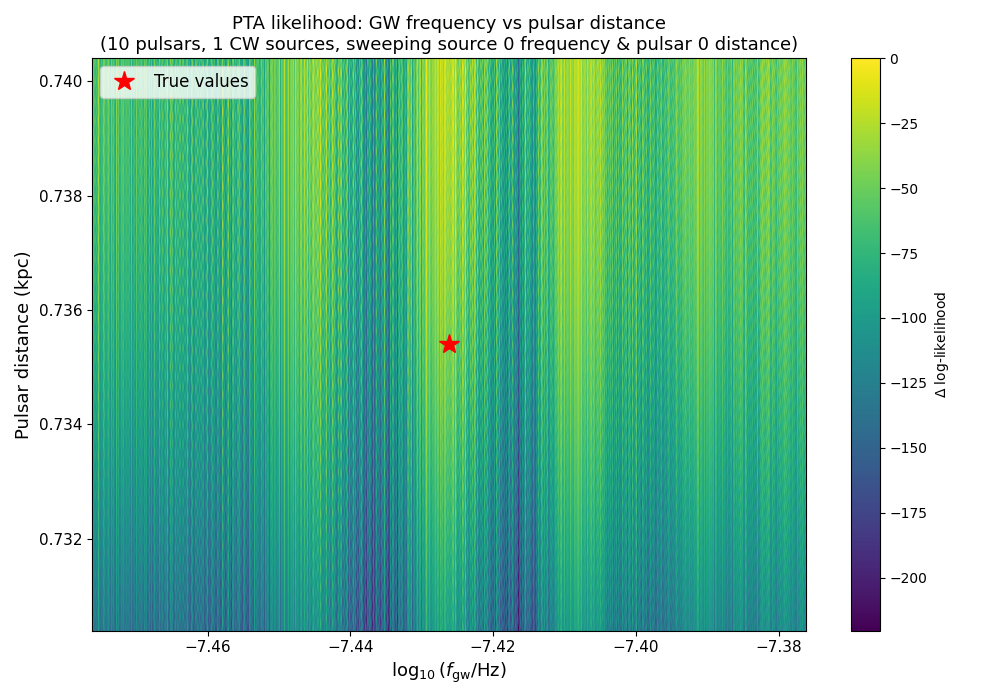

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))

delta_2d = logL_2d - logL_2d.max()
delta_2d = np.clip(delta_2d, -500, 0)

im = ax.pcolormesh(
    log10_fgw_grid, distance_grid, delta_2d,
    cmap="viridis", shading="auto",
)

ax.plot(TRUE_LOG10_FGW, true_distance, "r*", markersize=15, label="True values")

ax.set_xlabel(r"$\log_{10}(f_{\rm gw}/\rm Hz)$", fontsize=13)
ax.set_ylabel("Pulsar distance (kpc)", fontsize=13)
ax.set_title(
    f"PTA likelihood: GW frequency vs pulsar distance\n"
    f"({N_PULSARS} pulsars, {M_CW_SOURCES} CW sources, "
    f"sweeping source 0 frequency & pulsar {TARGET_PULSAR} distance)",
    fontsize=13,
)
ax.legend(fontsize=12, loc="upper left")
ax.tick_params(labelsize=11)
fig.colorbar(im, ax=ax, label=r"$\Delta$ log-likelihood")
fig.tight_layout()
plt.show()

## 1D likelihood sweep: log10(f_gw) at true distance

Slice through the 2D surface at the true pulsar distance to show
how the likelihood depends on GW frequency alone.

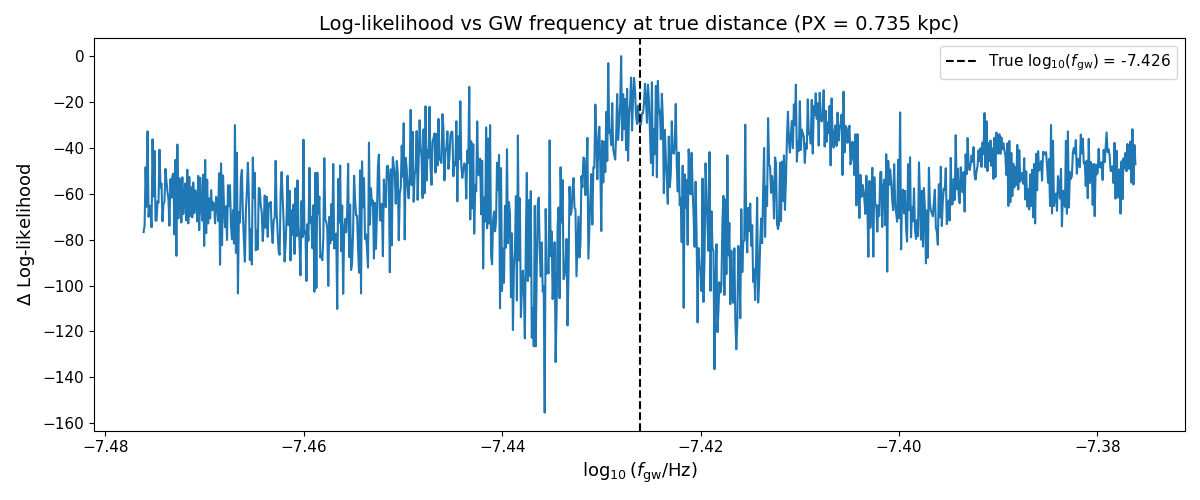

In [16]:
# Finer 1D grid over frequency at the true distance
log10_fgw_fine = np.linspace(
    TRUE_LOG10_FGW - half_window_fgw,
    TRUE_LOG10_FGW + half_window_fgw,
    1000,
)

# Vectorize over frequency, holding the distance fixed at the true value.
eval_1d = jax.jit(
    jax.vmap(lambda f: eval_logL_2d(f, jnp.float64(true_distance)))
)
_ = eval_1d(jnp.asarray(log10_fgw_fine[:2])).block_until_ready()

logL_1d = np.asarray(eval_1d(jnp.asarray(log10_fgw_fine)))

delta_1d = logL_1d - logL_1d.max()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(log10_fgw_fine, delta_1d, linewidth=1.5)
ax.axvline(TRUE_LOG10_FGW, color="black", linestyle="--", linewidth=1.5,
           label=f"True log$_{{10}}(f_{{\\rm gw}})$ = {TRUE_LOG10_FGW:.3f}")
ax.set_xlabel(r"$\log_{10}(f_{\rm gw}/\rm Hz)$", fontsize=13)
ax.set_ylabel(r"$\Delta$ Log-likelihood", fontsize=13)
ax.set_title(
    f"Log-likelihood vs GW frequency at true distance "
    f"(PX = {true_distance:.3f} kpc)",
    fontsize=14,
)
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()